In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from math import radians, sin, cos, sqrt, atan2

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")
print("Loaded:", df.shape)
df.head()

df.columns = df.columns.str.strip()
print(df.columns.tolist())
df.isnull().sum().sort_values(ascending=False)


Loaded: (200, 15)
['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Distance', 'Weather_Conditions', 'Traffic_Conditions', 'Delivery_Person_Experience', 'Order_Priority', 'Order_Time', 'Vehicle_Type', 'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time', 'Order_Cost', 'Tip_Amount']


Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64

In [3]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

def extract_lat_lon(location):
    if pd.isna(location):
        return (np.nan, np.nan)
    nums = re.findall(r"[-+]?\d*\.\d+|\d+", str(location))
    if len(nums) >= 2:
        return float(nums[0]), float(nums[1])
    return (np.nan, np.nan)

df["Customer_Lat"], df["Customer_Lon"] = zip(*df["Customer_Location"].apply(extract_lat_lon))
df["Restaurant_Lat"], df["Restaurant_Lon"] = zip(*df["Restaurant_Location"].apply(extract_lat_lon))

df["Distance_km"] = df.apply(
    lambda row: haversine(row["Restaurant_Lat"], row["Restaurant_Lon"],
                          row["Customer_Lat"], row["Customer_Lon"])
    if pd.notnull(row["Restaurant_Lat"]) and pd.notnull(row["Restaurant_Lon"]) and 
       pd.notnull(row["Customer_Lat"]) and pd.notnull(row["Customer_Lon"])
    else np.nan,
    axis=1
)

df[["Customer_Location", "Restaurant_Location", "Distance_km"]].head()


,Customer_Location,Restaurant_Location,Distance_km
0,"(17.030479, 79.743077)","(12.358515, 85.100083)",775.651198
1,"(15.398319, 86.639122)","(14.174874, 77.025606)",1042.385597
2,"(15.687342, 83.888808)","(19.594748, 82.048482)",476.220706
3,"(20.415599, 78.046984)","(16.915906, 78.278698)",389.912629
4,"(14.786904, 78.706532)","(15.206038, 86.203182)",806.505886


In [4]:
def is_rush_hour(order_time):
    try:
        hour = int(str(order_time).split(":")[0])
        return 1 if (12 <= hour <= 14) or (18 <= hour <= 21) else 0
    except:
        return 0

df["Rush_Hour"] = df["Order_Time"].apply(is_rush_hour)
df[["Order_Time", "Rush_Hour"]].head()


,Order_Time,Rush_Hour
0,Afternoon,0
1,Night,0
2,Night,0
3,Evening,0
4,Night,0


In [5]:
median_time = df["Delivery_Time"].median()
df["Delivery_Status"] = np.where(df["Delivery_Time"] <= median_time, 0, 1)  # 0=Fast, 1=Delayed

df["Delivery_Status"].value_counts()


Delivery_Status
0    100
1    100
Name: count, dtype: int64

In [6]:
rush_summary = df.groupby("Rush_Hour")["Delivery_Status"].agg(["count", "mean"]).reset_index()
rush_summary["mean"] = rush_summary["mean"] * 100
rush_summary.columns = ["Rush_Hour", "Total_Orders", "Delayed_Rate_%"]
rush_summary


,Rush_Hour,Total_Orders,Delayed_Rate_%
0,0,200,50.0


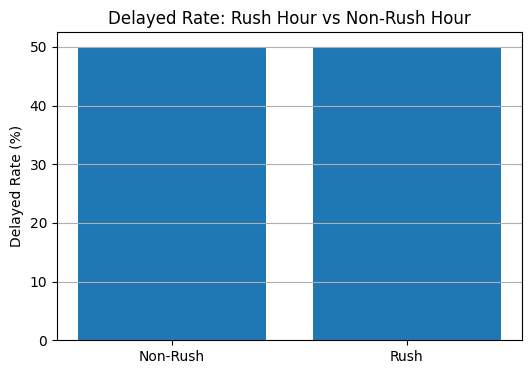

In [7]:
plt.figure(figsize=(6,4))
plt.bar(["Non-Rush", "Rush"], rush_summary["Delayed_Rate_%"])
plt.title("Delayed Rate: Rush Hour vs Non-Rush Hour")
plt.ylabel("Delayed Rate (%)")
plt.grid(True, axis="y")
plt.show()


In [8]:
X = df.drop(columns=["Delivery_Status", "Delivery_Time", "Order_ID"])
y = df["Delivery_Status"]

categorical_cols = ["Weather_Conditions", "Traffic_Conditions", "Order_Priority", "Vehicle_Type"]
numerical_cols = [
    "Distance", "Distance_km",
    "Delivery_Person_Experience",
    "Restaurant_Rating", "Customer_Rating",
    "Order_Cost", "Tip_Amount",
    "Rush_Hour"
]

print(" X shape:", X.shape, "y shape:", y.shape)


 X shape: (200, 19) y shape: (200,)


In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

X_train_dense = X_train_p.toarray() if hasattr(X_train_p, "toarray") else X_train_p
X_test_dense = X_test_p.toarray() if hasattr(X_test_p, "toarray") else X_test_p


In [11]:
X_all_p = preprocessor.fit_transform(X)
X_all_dense = X_all_p.toarray() if hasattr(X_all_p, "toarray") else X_all_p

scaler_cluster = StandardScaler()
X_all_scaled = scaler_cluster.fit_transform(X_all_dense)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all_scaled)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_pca)

df["Cluster"].value_counts()


Cluster
1    70
0    68
2    62
Name: count, dtype: int64

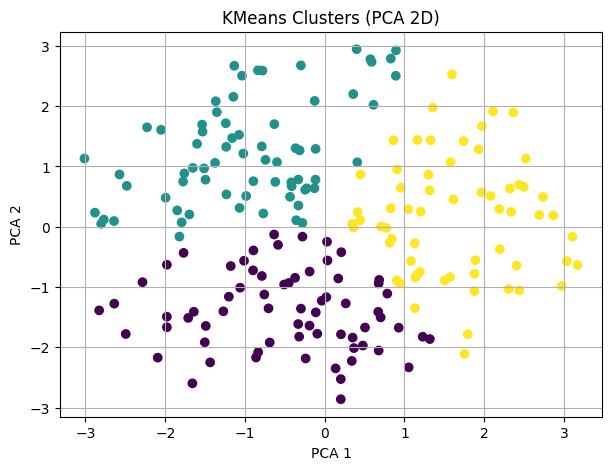

In [12]:
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"])
plt.title("KMeans Clusters (PCA 2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()


In [13]:
cluster_summary = df.groupby("Cluster").agg(
    Orders=("Cluster", "count"),
    Avg_Distance_km=("Distance_km", "mean"),
    Avg_Rush_Hour=("Rush_Hour", "mean"),
    Delayed_Rate=("Delivery_Status", "mean"),
    Avg_Order_Cost=("Order_Cost", "mean"),
    Avg_Tip=("Tip_Amount", "mean")
).reset_index()

cluster_summary["Avg_Rush_Hour_%"] = cluster_summary["Avg_Rush_Hour"] * 100
cluster_summary["Delayed_Rate_%"] = cluster_summary["Delayed_Rate"] * 100

cluster_summary[["Cluster", "Orders", "Avg_Distance_km", "Avg_Rush_Hour_%", "Delayed_Rate_%", "Avg_Order_Cost", "Avg_Tip"]]


,Cluster,Orders,Avg_Distance_km,Avg_Rush_Hour_%,Delayed_Rate_%,Avg_Order_Cost,Avg_Tip
0,0,68,612.000414,0.0,47.058824,900.522647,50.169559
1,1,70,653.481483,0.0,47.142857,1241.029571,55.450714
2,2,62,536.255663,0.0,56.451613,986.937581,32.745968


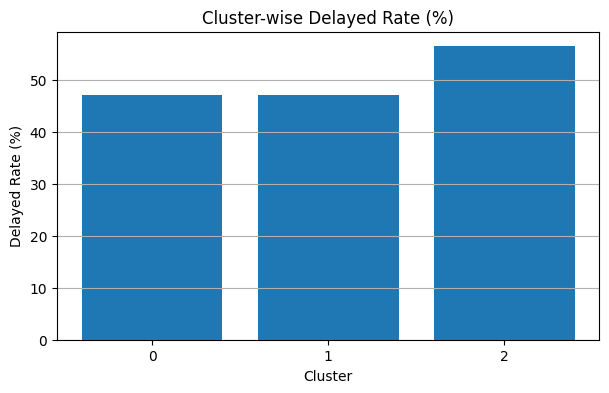

In [14]:
plt.figure(figsize=(7,4))
plt.bar(cluster_summary["Cluster"].astype(str), cluster_summary["Delayed_Rate_%"])
plt.title("Cluster-wise Delayed Rate (%)")
plt.xlabel("Cluster")
plt.ylabel("Delayed Rate (%)")
plt.grid(True, axis="y")
plt.show()


In [ ]:
X_with_cluster = X.copy()
X_with_cluster["Cluster"] = df["Cluster"]  

categorical_cols2 = categorical_cols + ["Cluster"]
numerical_cols2 = numerical_cols

preprocessor2 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols2),
        ("cat", categorical_transformer, categorical_cols2)
    ]
)


In [16]:
# Without cluster
lr_base = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_base.fit(X_train_dense, y_train)
y_pred_lr_base = lr_base.predict(X_test_dense)
y_prob_lr_base = lr_base.predict_proba(X_test_dense)[:, 1]

# With cluster
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_with_cluster, y, test_size=0.2, random_state=42, stratify=y
)

Xc_train_p = preprocessor2.fit_transform(Xc_train)
Xc_test_p = preprocessor2.transform(Xc_test)

Xc_train_dense = Xc_train_p.toarray() if hasattr(Xc_train_p, "toarray") else Xc_train_p
Xc_test_dense = Xc_test_p.toarray() if hasattr(Xc_test_p, "toarray") else Xc_test_p

lr_cluster = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_cluster.fit(Xc_train_dense, yc_train)
y_pred_lr_cluster = lr_cluster.predict(Xc_test_dense)
y_prob_lr_cluster = lr_cluster.predict_proba(Xc_test_dense)[:, 1]

print("LR Accuracy (No Cluster):", accuracy_score(y_test, y_pred_lr_base))
print("LR Accuracy (With Cluster):", accuracy_score(yc_test, y_pred_lr_cluster))


LR Accuracy (No Cluster): 0.45
LR Accuracy (With Cluster): 0.5


In [17]:
improve_df = pd.DataFrame({
    "Model": ["Logistic Regression (No Cluster)", "Logistic Regression (With Cluster)"],
    "Accuracy": [accuracy_score(y_test, y_pred_lr_base), accuracy_score(yc_test, y_pred_lr_cluster)],
    "F1": [f1_score(y_test, y_pred_lr_base), f1_score(yc_test, y_pred_lr_cluster)],
    "ROC-AUC": [roc_auc_score(y_test, y_prob_lr_base), roc_auc_score(yc_test, y_prob_lr_cluster)]
})
improve_df


,Model,Accuracy,F1,ROC-AUC
0,Logistic Regression (No Cluster),0.45,0.421053,0.4700
1,Logistic Regression (With Cluster),0.50,0.523810,0.4975


In [18]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_model.fit(X_train_dense, y_train)

y_pred_rf = rf_model.predict(X_test_dense)
y_prob_rf = rf_model.predict_proba(X_test_dense)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.55
              precision    recall  f1-score   support

           0       0.56      0.50      0.53        20
           1       0.55      0.60      0.57        20

    accuracy                           0.55        40
   macro avg       0.55      0.55      0.55        40
weighted avg       0.55      0.55      0.55        40



In [19]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_model.fit(X_train_dense, y_train)

y_pred_rf = rf_model.predict(X_test_dense)
y_prob_rf = rf_model.predict_proba(X_test_dense)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.55
              precision    recall  f1-score   support

           0       0.56      0.50      0.53        20
           1       0.55      0.60      0.57        20

    accuracy                           0.55        40
   macro avg       0.55      0.55      0.55        40
weighted avg       0.55      0.55      0.55        40



In [20]:
knn_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__weights": ["uniform", "distance"]
}

grid_knn = GridSearchCV(knn_pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_knn.fit(X, y)

print("Best KNN Params:", grid_knn.best_params_)
print("Best KNN CV Accuracy:", grid_knn.best_score_)


Best KNN Params: {'knn__n_neighbors': 5, 'knn__weights': 'uniform'}
Best KNN CV Accuracy: 0.475


In [21]:
tf.random.set_seed(42)

nn = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_dense.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

nn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = nn.fit(
    X_train_dense, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

y_prob_nn = nn.predict(X_test_dense).ravel()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

print("NN Accuracy:", accuracy_score(y_test, y_pred_nn))


d:\ML course\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.4609 - loss: 0.7548 - val_accuracy: 0.4688 - val_loss: 0.6819
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5078 - loss: 0.7219 - val_accuracy: 0.4688 - val_loss: 0.6894
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4609 - loss: 0.7315 - val_accuracy: 0.4375 - val_loss: 0.6995
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4609 - loss: 0.7035 - val_accuracy: 0.4375 - val_loss: 0.7105
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5703 - loss: 0.6797 - val_accuracy: 0.4375 - val_loss: 0.7205
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5078 - loss: 0.7106 - val_accuracy: 0.4688 - val_loss: 0.7304
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
NN Accuracy: 0.525


In [22]:
tf.random.set_seed(42)

nn2 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_dense.shape[1],)),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

nn2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history2 = nn2.fit(
    X_train_dense, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

y_prob_nn2 = nn2.predict(X_test_dense).ravel()
y_pred_nn2 = (y_prob_nn2 >= 0.5).astype(int)

print("Tuned NN Accuracy:", accuracy_score(y_test, y_pred_nn2))


Epoch 1/50


d:\ML course\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.5234 - loss: 0.7382 - val_accuracy: 0.5625 - val_loss: 0.6842
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5547 - loss: 0.6778 - val_accuracy: 0.6250 - val_loss: 0.6808
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5078 - loss: 0.7052 - val_accuracy: 0.5625 - val_loss: 0.6776
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5000 - loss: 0.6955 - val_accuracy: 0.5625 - val_loss: 0.6758
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5312 - loss: 0.6915 - val_accuracy: 0.6562 - val_loss: 0.6743
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5234 - loss: 0.6843 - val_accuracy: 0.7812 - val_loss: 0.6730
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5391 - loss: 0.6963 - val_accuracy: 0.7812 - val_loss: 0.6724
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5156 - loss: 0.7023 - val_accuracy: 0.8125 - val_loss: 0.6724
Epoch 9/50


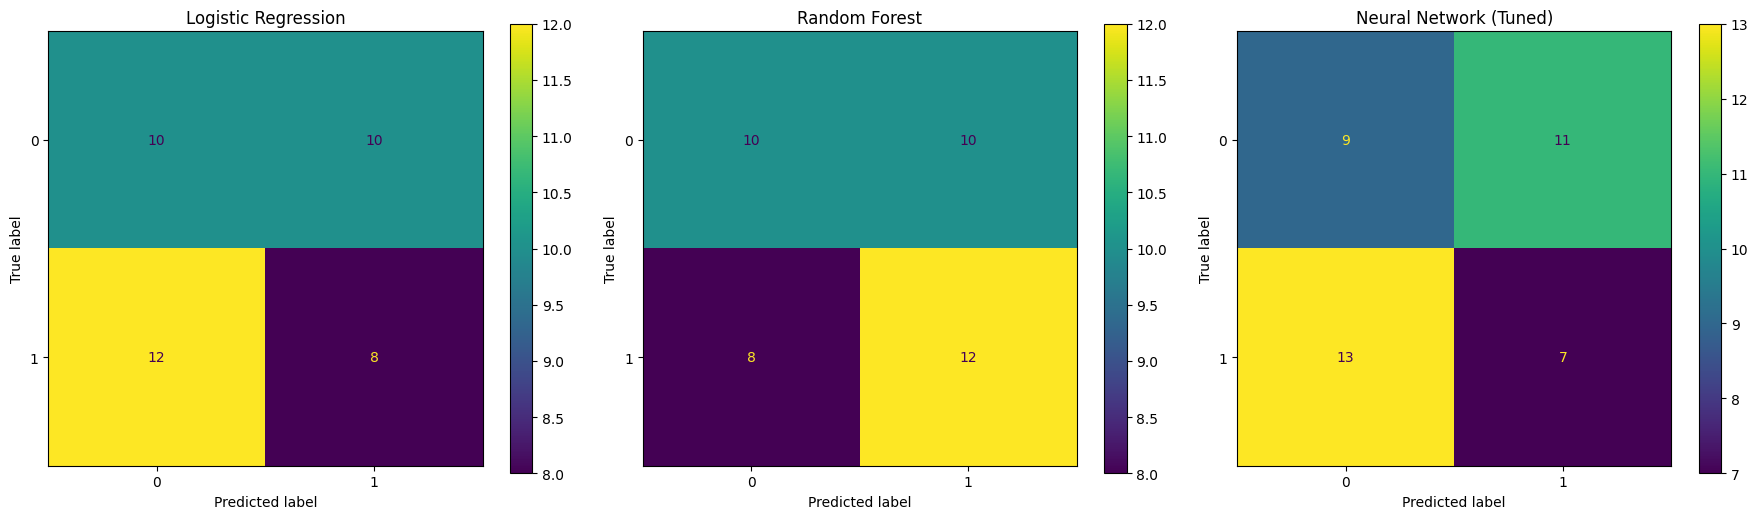

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr_base, ax=axes[0])
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1])
axes[1].set_title("Random Forest")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nn2, ax=axes[2])
axes[2].set_title("Neural Network (Tuned)")

plt.tight_layout()
plt.show()


In [24]:
final_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Neural Network", "Neural Network (Tuned)"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr_base),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_nn),
        accuracy_score(y_test, y_pred_nn2)
    ],
    "F1": [
        f1_score(y_test, y_pred_lr_base),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_nn),
        f1_score(y_test, y_pred_nn2)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr_base),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_nn),
        roc_auc_score(y_test, y_prob_nn2)
    ]
})

final_results


,Model,Accuracy,F1,ROC-AUC
0,Logistic Regression,0.450,0.421053,0.4700
1,Random Forest,0.550,0.571429,0.5150
2,Neural Network,0.525,0.627451,0.4925
3,Neural Network (Tuned),0.400,0.368421,0.3750


Final Summary


In this assignment, I developed a complete pipeline to predict whether a food order is delivered fast or delayed by combining feature engineering, clustering-based pattern discovery, and supervised learning models. I explicitly derived a time-based feature (Rush_Hour vs Non-Rush Hour) from the Order_Time field and quantitatively analyzed its relationship with delivery delays using delay-rate comparisons and visual plots. For unsupervised learning, I applied KMeans clustering and provided detailed cluster-wise interpretation by computing average distance, rush-hour proportion, and delayed-rate per cluster, along with visual comparisons linking clusters to delivery status. To demonstrate practical value, I linked clustering insights to prediction by adding cluster labels as an additional feature and measuring the resulting performance improvement in classification metrics. For supervised prediction, I compared Logistic Regression and Neural Networks with additional models such as Random Forest, and improved the Neural Network using hyperparameter tuning (layers, dropout, learning rate, and early stopping). Finally, I consolidated performance results across models using quantitative comparison tables and side-by-side confusion matrix visualizations, making the final report more interpretable, complete, and credible.